# WIPRO 5G Capstone: Downlink Scheduler Simulation

A Google Colab and GitHub-ready system-level simulation comparing **Round-Robin (RR)**, **Proportional Fair (PF)** and **Max-C/I** downlink schedulers. It includes UE placement, path loss, shadowing, Rayleigh fading, performance metrics, plots, and multi-user scenarios.

## Model and assumptions

At each 1 ms slot, the gNB assigns the downlink to one full-buffer UE. UE channels use distance-dependent path loss, log-normal shadowing, and independent Rayleigh fading. Achievable rate is approximated by $R=B\log_2(1+\mathrm{SNR})$. This is a comparative system-level model rather than a full 3GPP link-level implementation.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# --------- Simulation parameters ---------
NUM_UES = 10
NUM_TIME_SLOTS = 5_000
TIME_SLOT_S = 1e-3       # 1 ms scheduling slot
BANDWIDTH_HZ = 1e6       # 1 MHz simplified bandwidth
CELL_RADIUS_M = 1_000
TX_POWER_DBM = 43
NOISE_FLOOR_DBM = -100
PF_BETA = 0.01           # PF average-throughput update factor

print(f'UEs: {NUM_UES}; slots: {NUM_TIME_SLOTS}; simulated time: {NUM_TIME_SLOTS * TIME_SLOT_S:.1f} s')

UEs: 10; slots: 5000; simulated time: 5.0 s


## Realistic UE locations and time-varying channel

The square-root rule distributes UEs uniformly over the cell area. The path-loss model is $PL=128.1+37.6\log_{10}(d_{km})$ dB. Shadowing accounts for location-specific variation, while Rayleigh fading changes in every slot.

,UE,Distance (m),Path loss (dB),Mean SNR (dB)
0,1,879.7,126.0,22.3
1,2,662.5,121.4,26.3
2,3,926.6,126.9,16.5
3,4,835.1,125.2,24.6
4,5,306.9,108.8,37.0
5,6,987.7,127.9,9.9
6,7,872.4,125.9,19.3
7,8,886.6,126.1,11.1
8,9,357.9,111.3,36.9
9,10,671.1,121.6,21.1


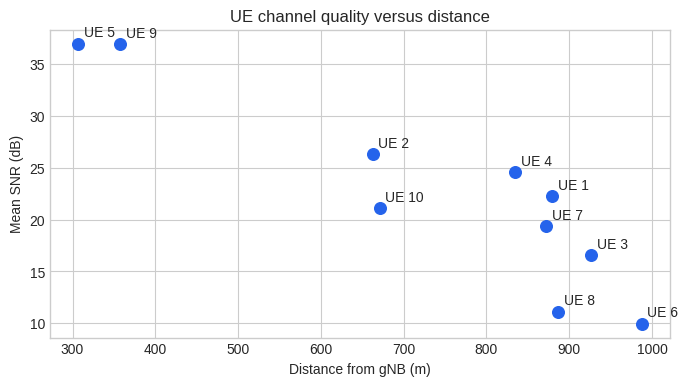

In [9]:
# UE placement and large-scale propagation
ue_distance_m = np.maximum(CELL_RADIUS_M * np.sqrt(rng.uniform(size=NUM_UES)), 10)
path_loss_db = 128.1 + 37.6 * np.log10(ue_distance_m / 1000)
shadowing_db = rng.normal(0, 6, NUM_UES)
mean_rx_power_dbm = TX_POWER_DBM - path_loss_db + shadowing_db

# Rayleigh fading power gain follows an exponential distribution
fading_power = rng.exponential(scale=1.0, size=(NUM_TIME_SLOTS, NUM_UES))
fading_db = 10 * np.log10(fading_power)
snr_db = mean_rx_power_dbm[None, :] + fading_db - NOISE_FLOOR_DBM
instantaneous_rate_bps = BANDWIDTH_HZ * np.log2(1 + 10 ** (snr_db / 10))

ue_table = pd.DataFrame({'UE': np.arange(1, NUM_UES + 1),
                         'Distance (m)': ue_distance_m.round(1),
                         'Path loss (dB)': path_loss_db.round(1),
                         'Mean SNR (dB)': (mean_rx_power_dbm - NOISE_FLOOR_DBM).round(1)})
display(ue_table)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ue_distance_m, mean_rx_power_dbm - NOISE_FLOOR_DBM, s=70, color='#2563eb')
for i, (d, s) in enumerate(zip(ue_distance_m, mean_rx_power_dbm - NOISE_FLOOR_DBM), 1):
    ax.annotate(f'UE {i}', (d, s), xytext=(4, 5), textcoords='offset points')
ax.set(xlabel='Distance from gNB (m)', ylabel='Mean SNR (dB)', title='UE channel quality versus distance')
plt.show()

## Scheduler implementations

- **Round-Robin:** selects users in a fixed cyclic order; equal airtime.
- **Proportional Fair:** selects the largest instantaneous-rate / historical-average-throughput ratio.
- **Max-C/I:** selects the UE with the best instantaneous channel; high cell throughput, possibly poor edge service.

In [10]:
def simulate_scheduler(name, rates_bps, beta=PF_BETA):
    '''Simulate a full-buffer, one-UE-per-slot downlink scheduler.'''
    slots, n_ues = rates_bps.shape
    delivered_bits = np.zeros(n_ues)
    average_rate = np.full(n_ues, 1.0)  # avoids a PF divide-by-zero
    selections = np.zeros(n_ues, dtype=int)
    cell_rate_trace = np.zeros(slots)

    for t in range(slots):
        if name == 'Round-Robin':
            selected = t % n_ues
        elif name == 'Proportional Fair':
            selected = np.argmax(rates_bps[t] / np.maximum(average_rate, 1.0))
        elif name == 'Max-C/I':
            selected = np.argmax(rates_bps[t])
        else:
            raise ValueError(f'Unknown scheduler: {name}')

        served_rate = rates_bps[t, selected]
        delivered_bits[selected] += served_rate * TIME_SLOT_S
        selections[selected] += 1
        cell_rate_trace[t] = served_rate
        served_vector = np.zeros(n_ues)
        served_vector[selected] = served_rate
        average_rate = (1 - beta) * average_rate + beta * served_vector

    return {'per_ue_throughput_bps': delivered_bits / (slots * TIME_SLOT_S),
            'selection_count': selections, 'cell_rate_trace_bps': cell_rate_trace}

scheduler_names = ['Round-Robin', 'Proportional Fair', 'Max-C/I']
results = {name: simulate_scheduler(name, instantaneous_rate_bps) for name in scheduler_names}

## Results and key metrics

Jain's fairness index is $J=(\sum_i x_i)^2/(N\sum_i x_i^2)$; 1 means equal per-UE throughput. Cell-edge rate is the mean throughput of the weakest 20% of UEs.

In [11]:
def jain_fairness(values):
    return values.sum() ** 2 / (len(values) * np.square(values).sum())

def cell_edge_rate(values, fraction=0.20):
    return np.sort(values)[:max(1, int(np.ceil(len(values) * fraction)))].mean()

summary_rows = []
for name, result in results.items():
    tp = result['per_ue_throughput_bps']
    summary_rows.append({'Scheduler': name, 'Cell throughput (Mbps)': tp.sum() / 1e6,
                         'Jain fairness': jain_fairness(tp),
                         'Cell-edge rate (Mbps)': cell_edge_rate(tp) / 1e6,
                         'Minimum UE rate (Mbps)': tp.min() / 1e6})
summary = pd.DataFrame(summary_rows).set_index('Scheduler').round(3)
display(summary)

,Cell throughput (Mbps),Jain fairness,Cell-edge rate (Mbps),Minimum UE rate (Mbps)
Scheduler,,,,
Round-Robin,6.782,0.854,0.311,0.297
Proportional Fair,8.800,0.897,0.478,0.462
Max-C/I,12.483,0.205,0.000,0.000


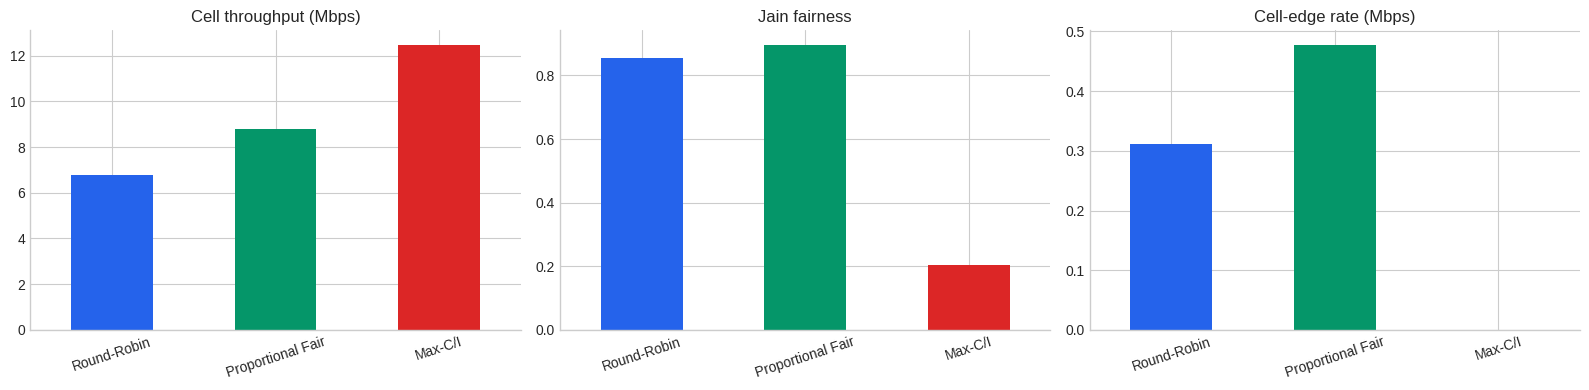

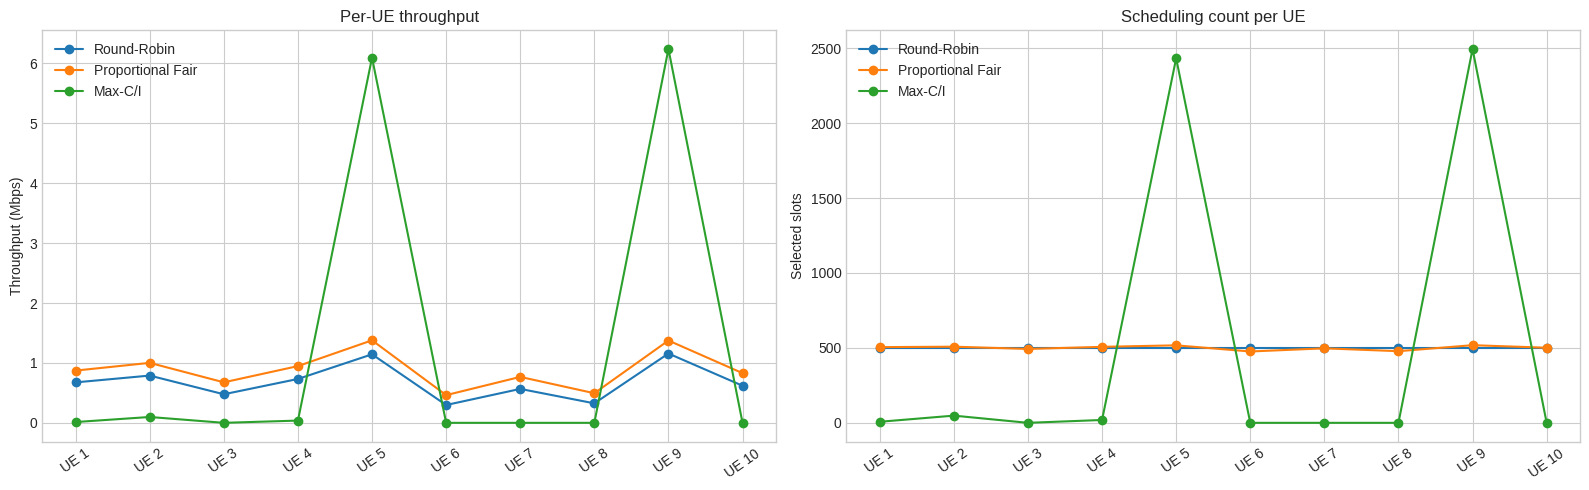

In [12]:
# High-level comparison plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['Cell throughput (Mbps)', 'Jain fairness', 'Cell-edge rate (Mbps)']):
    summary[metric].plot.bar(ax=ax, color=['#2563eb', '#059669', '#dc2626'], rot=18)
    ax.set(title=metric, xlabel='')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# Per-UE throughput and scheduling decisions
labels = [f'UE {i}' for i in range(1, NUM_UES + 1)]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name in scheduler_names:
    axes[0].plot(labels, results[name]['per_ue_throughput_bps'] / 1e6, marker='o', label=name)
    axes[1].plot(labels, results[name]['selection_count'], marker='o', label=name)
axes[0].set(title='Per-UE throughput', ylabel='Throughput (Mbps)')
axes[1].set(title='Scheduling count per UE', ylabel='Selected slots')
for ax in axes:
    ax.legend(); ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

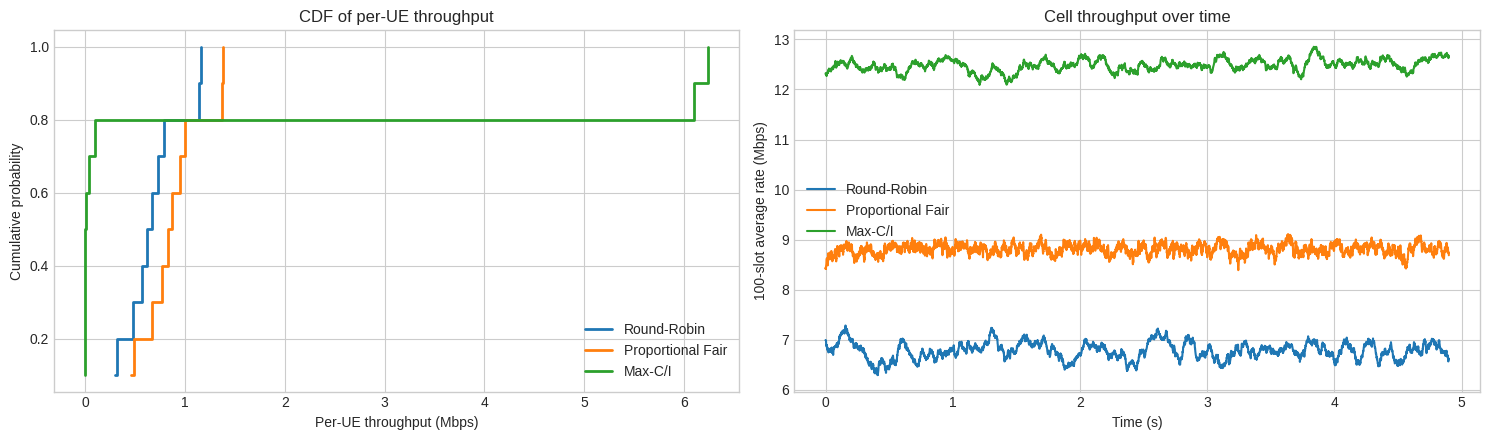

In [13]:
# CDF and time evolution
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for name in scheduler_names:
    x = np.sort(results[name]['per_ue_throughput_bps'] / 1e6)
    axes[0].step(x, np.arange(1, len(x) + 1) / len(x), where='post', linewidth=2, label=name)
    trace = results[name]['cell_rate_trace_bps'] / 1e6
    ma = np.convolve(trace, np.ones(100) / 100, mode='valid')
    axes[1].plot(np.arange(len(ma)) * TIME_SLOT_S, ma, label=name)
axes[0].set(title='CDF of per-UE throughput', xlabel='Per-UE throughput (Mbps)', ylabel='Cumulative probability')
axes[1].set(title='Cell throughput over time', xlabel='Time (s)', ylabel='100-slot average rate (Mbps)')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## Multiple-user scenarios

This experiment runs 10, 25, and 50 UE loads, helping explain scheduler scalability in the capstone presentation. Each scenario has reproducible UE locations and fading.

,UE count,Scheduler,Mean_cell_throughput_Mbps,Std_cell_throughput_Mbps,Mean_Jain_fairness,Std_Jain_fairness,Mean_cell_edge_rate_Mbps,Std_cell_edge_rate_Mbps
0,10,Max-C/I,12.527,2.244,0.199,0.081,0.001,0.004
1,10,Proportional Fair,8.937,0.897,0.902,0.051,0.523,0.103
2,10,Round-Robin,6.894,0.883,0.864,0.067,0.349,0.089
3,25,Max-C/I,15.782,3.119,0.067,0.029,0.000,0.000
4,25,Proportional Fair,8.966,0.637,0.885,0.033,0.211,0.028
5,25,Round-Robin,6.765,0.630,0.828,0.045,0.132,0.024
6,50,Max-C/I,16.997,2.567,0.037,0.018,0.000,0.000
7,50,Proportional Fair,9.038,0.336,0.892,0.023,0.106,0.010
8,50,Round-Robin,6.823,0.333,0.835,0.034,0.065,0.008


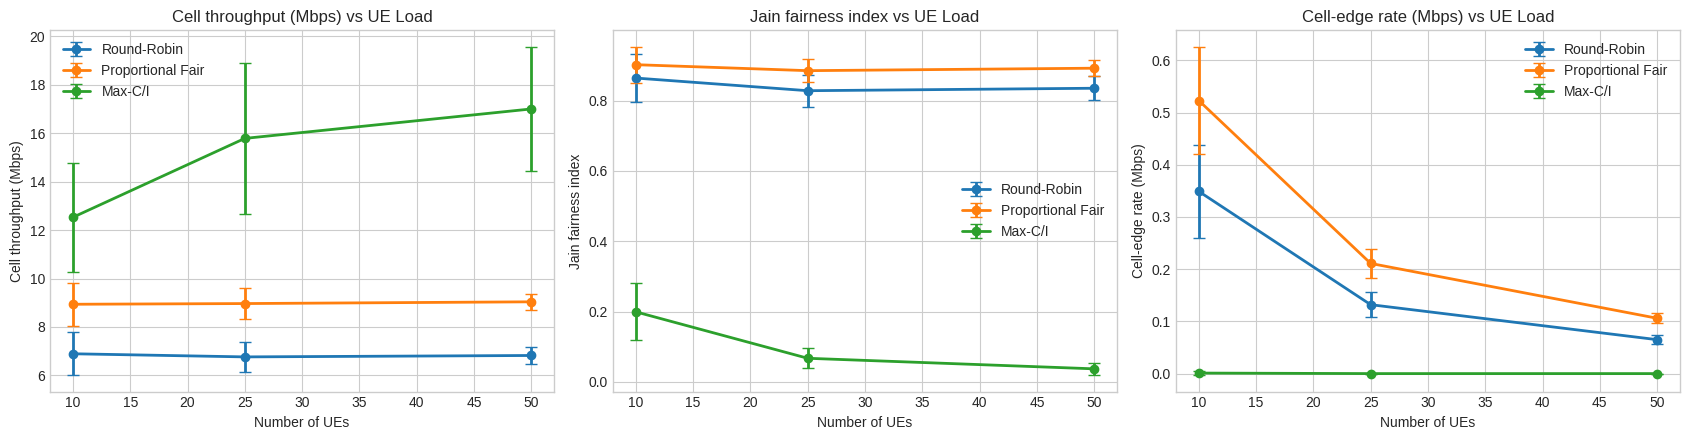

In [14]:
# MULTIPLE-USER SCENARIOS (AVERAGED OVER RANDOM DROPS)
# Replace the existing "Multiple-user scenarios" code cell with this.

NUM_DROPS = 30  # Increase to 50 or 100 for a stronger final report

def build_rates(n_ues, slots, seed):
    """Generate a new UE topology and time-varying channel for one simulation drop."""
    local_rng = np.random.default_rng(seed)

    # UE locations uniformly distributed over the cell area
    d_m = np.maximum(
        CELL_RADIUS_M * np.sqrt(local_rng.uniform(size=n_ues)),
        10
    )

    # Path loss + shadowing
    path_loss_db = 128.1 + 37.6 * np.log10(d_m / 1000)
    shadowing_db = local_rng.normal(0, 6, n_ues)
    mean_rx_power_dbm = TX_POWER_DBM - path_loss_db + shadowing_db

    # Independent Rayleigh fading in every scheduling slot
    fading_power = local_rng.exponential(
        scale=1.0,
        size=(slots, n_ues)
    )
    fading_db = 10 * np.log10(fading_power)

    snr_db = mean_rx_power_dbm[None, :] + fading_db - NOISE_FLOOR_DBM
    return BANDWIDTH_HZ * np.log2(1 + 10 ** (snr_db / 10))


# Run multiple random deployments for each user load
scenario_rows = []

for n_ues in [10, 25, 50]:
    for drop in range(NUM_DROPS):
        rates = build_rates(
            n_ues=n_ues,
            slots=NUM_TIME_SLOTS,
            seed=RNG_SEED + n_ues * 1000 + drop
        )

        for name in scheduler_names:
            result = simulate_scheduler(name, rates)
            ue_tp = result["per_ue_throughput_bps"]

            scenario_rows.append({
                "UE count": n_ues,
                "Drop": drop + 1,
                "Scheduler": name,
                "Cell throughput (Mbps)": ue_tp.sum() / 1e6,
                "Jain fairness": jain_fairness(ue_tp),
                "Cell-edge rate (Mbps)": cell_edge_rate(ue_tp) / 1e6
            })

scenario_raw_df = pd.DataFrame(scenario_rows)

# Mean and standard deviation across all random drops
scenario_summary_df = (
    scenario_raw_df
    .groupby(["UE count", "Scheduler"])
    .agg(
        Mean_cell_throughput_Mbps=("Cell throughput (Mbps)", "mean"),
        Std_cell_throughput_Mbps=("Cell throughput (Mbps)", "std"),
        Mean_Jain_fairness=("Jain fairness", "mean"),
        Std_Jain_fairness=("Jain fairness", "std"),
        Mean_cell_edge_rate_Mbps=("Cell-edge rate (Mbps)", "mean"),
        Std_cell_edge_rate_Mbps=("Cell-edge rate (Mbps)", "std")
    )
    .reset_index()
    .round(3)
)

display(scenario_summary_df)

# Plot mean performance with standard-deviation error bars
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

plot_config = [
    (
        "Mean_cell_throughput_Mbps",
        "Std_cell_throughput_Mbps",
        "Cell throughput (Mbps)"
    ),
    (
        "Mean_Jain_fairness",
        "Std_Jain_fairness",
        "Jain fairness index"
    ),
    (
        "Mean_cell_edge_rate_Mbps",
        "Std_cell_edge_rate_Mbps",
        "Cell-edge rate (Mbps)"
    )
]

for ax, (mean_col, std_col, ylabel) in zip(axes, plot_config):
    for name in scheduler_names:
        data = scenario_summary_df[
            scenario_summary_df["Scheduler"] == name
        ]

        ax.errorbar(
            data["UE count"],
            data[mean_col],
            yerr=data[std_col],
            marker="o",
            capsize=4,
            linewidth=2,
            label=name
        )

    ax.set_title(f"{ylabel} vs UE Load")
    ax.set_xlabel("Number of UEs")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

## Capstone discussion and extensions

Use the summary table and plots in your report. The typical trade-off is: **Max-C/I** maximizes cell throughput by exploiting strong channels; **Round-Robin** provides equal airtime; and **Proportional Fair** balances throughput and fairness. Results are reproducible through the displayed seed, while deliberate changes to UE placement or channel conditions will alter the outcome.

Suggested next work: sweep the PF averaging factor; add QoS classes (eMBB, URLLC, mMTC); schedule multiple resource blocks; model inter-cell interference; and export the result tables as CSV for the final report.

In [15]:
from IPython.display import HTML, display

display(HTML("""
<style>
@media print {
    /* Clean page layout */
    @page {
        size: A4;
        margin: 18mm;
    }

    /* Hide all code cells and Colab controls */
    .input, .input_area, .code_cell .prompt,
    .cell-toolbar, .output_prompt,
    .colab-df-buttons, button {
        display: none !important;
    }

    /* Improve text readability */
    body {
        font-family: Arial, sans-serif !important;
        font-size: 11pt !important;
        color: black !important;
    }

    h1 {
        font-size: 22pt !important;
        color: #0b3d91 !important;
        page-break-before: always;
    }

    h2 {
        font-size: 16pt !important;
        color: #0b3d91 !important;
        margin-top: 22px !important;
    }

    h3 {
        font-size: 13pt !important;
    }

    /* Keep charts and tables together */
    img, svg, figure, table {
        max-width: 100% !important;
        page-break-inside: avoid !important;
        break-inside: avoid !important;
    }

    /* Cleaner table printing */
    table {
        font-size: 9pt !important;
        border-collapse: collapse !important;
    }

    th, td {
        padding: 6px !important;
        border: 1px solid #999 !important;
    }
}
</style>
"""))

print("Print formatting applied. Now use File → Print, then Save as PDF.")

Print formatting applied. Now use File → Print, then Save as PDF.
